# Visualize CutMix Augmentation
This notebook demonstrates the output of the CutMix augmentation on different images, drawing a colored boundary box around the CutMix patch for each image.

## 1. Create a New Git Branch
Use the integrated terminal in Visual Studio Code to create a new branch named 'testing' with:

```
git checkout -b testing
```

In [4]:
%pip install scikit-image

# Visualize CutMix on test set images using your project logic
import sys
import os
SCRIPT_DIR = os.getcwd()
PROJECT_ROOT = os.path.abspath(os.path.join(SCRIPT_DIR, '..'))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import torch
from torch.utils.data import DataLoader
from src.data.coco_dataset import COCODataset, ImageSegmentationDataset
from src.data.cutmix import get_cutmix_transform
from src.utils.palette import label2id, palette
import matplotlib.pyplot as plt
import numpy as np
from PIL import ImageDraw, Image
import matplotlib.colors as mcolors

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [6]:
# --- Config ---
coco_json = '/Users/rk/Downloads/Thesis/CKA_sweet_pepper_2020_summer/CKA_sweet_pepper_2020_summer.json'
img_root = '/Users/rk/Downloads/Thesis/'
batch_size = 4
num_classes = len(label2id)

# --- Load test set ---
base_dataset = COCODataset(coco_json, img_root, split='test')
dataset = ImageSegmentationDataset(base_dataset, label2id=label2id)
test_loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

# --- Get a batch ---
images, masks, orig_imgs, orig_masks = next(iter(test_loader))

# --- Apply CutMix ---
cutmix = get_cutmix_transform(num_classes, alpha=1.0, prob=1.0, save_samples=False)
# Patch coordinates will be extracted from the CutMix logic
# We'll monkey-patch the _cutmix method to return the box

def cutmix_with_box(self, imgs, masks):
    B, _, H, W = imgs.shape
    mix_imgs = imgs.clone()
    mix_masks = masks.clone()
    patch_boxes = []
    source_indices = []
    for i in range(B):
        lam = np.random.beta(self.alpha, self.alpha) if self.alpha > 0 else 1.
        rw, rh = int(W * np.sqrt(1 - lam)), int(H * np.sqrt(1 - lam))
        cx, cy = np.random.randint(W), np.random.randint(H)
        x1, y1 = np.clip(cx - rw // 2, 0, W), np.clip(cy - rh // 2, 0, H)
        x2, y2 = np.clip(cx + rw // 2, 0, W), np.clip(cy + rh // 2, 0, H)
        j = (i + 1) % B
        mix_imgs[i,:, y1:y2, x1:x2] = imgs[j,:, y1:y2, x1:x2]
        mix_masks[i, y1:y2, x1:x2] = masks[j, y1:y2, x1:x2]
        patch_boxes.append((x1, y1, x2, y2))
        source_indices.append(j)
    return mix_imgs, mix_masks, patch_boxes, source_indices

# Use our patched version for this notebook
mix_imgs, mix_masks, patch_boxes, source_indices = cutmix_with_box(cutmix, images, masks)

# --- Denormalize helper ---
ADE_MEAN = np.array([123.675, 116.280, 103.530]) / 255.0
ADE_STD  = np.array([58.395,  57.120,  57.375]) / 255.0
def denormalize(img):
    mean = torch.tensor(ADE_MEAN).view(3,1,1)
    std = torch.tensor(ADE_STD).view(3,1,1)
    img = torch.clamp(img * std + mean, 0, 1)
    return img


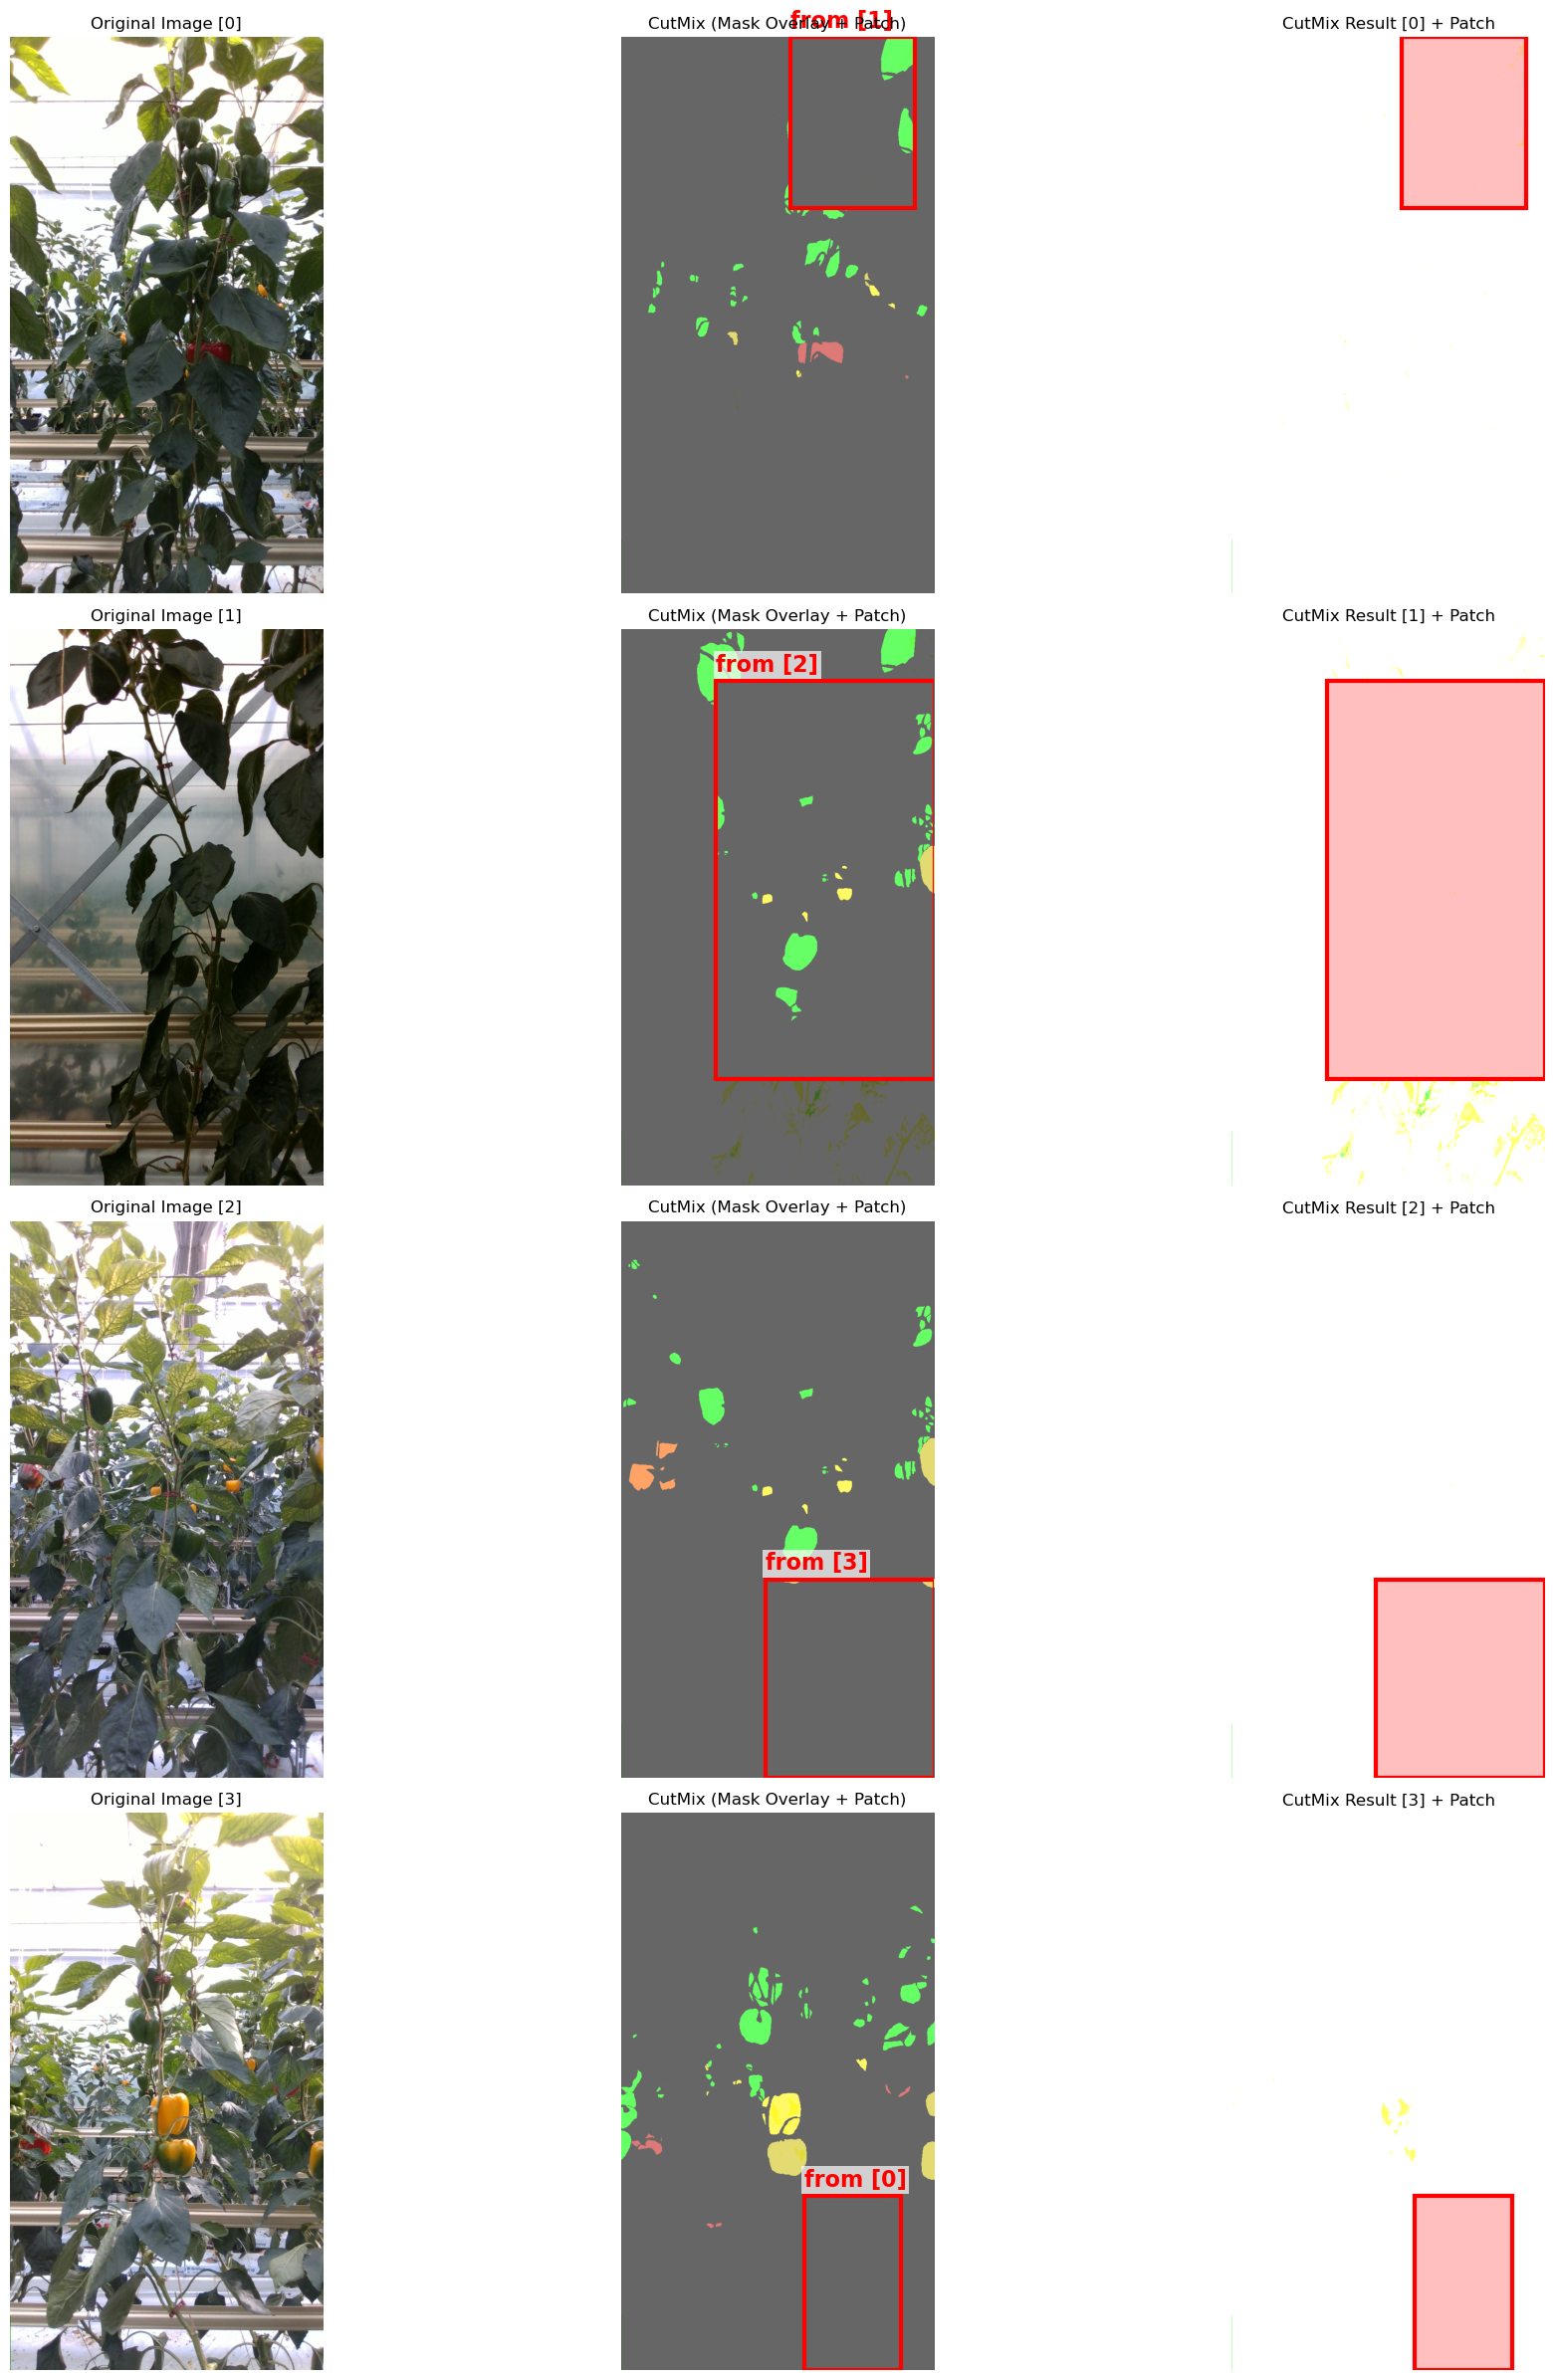

In [7]:
# --- CutMix Visualization ---
# This section visualizes the CutMix augmentation results for a batch of images.
# Columns:
#   1. Original image
#   2. CutMix image with mask overlay and patch boundary (shows pasted region and source index)
#   3. CutMix result image with patch region highlighted (semi-transparent red overlay + bounding box)

custom_cmap = mcolors.ListedColormap(np.array(palette) / 255.0)
fig, axs = plt.subplots(batch_size, 3, figsize=(21, 6 * batch_size))
for i in range(batch_size):
    # Original image
    axs[i,0].imshow(orig_imgs[i])
    axs[i,0].set_title(f'Original Image [{i}]')
    axs[i,0].axis('off')

    # CutMix image with mask overlay and boundary
    img = denormalize(mix_imgs[i]).permute(1,2,0).numpy()
    mask = mix_masks[i].cpu().numpy()
    axs[i,1].imshow(img)
    axs[i,1].imshow(mask, cmap=custom_cmap, vmin=0, vmax=len(palette)-1, alpha=0.6)
    x1, y1, x2, y2 = patch_boxes[i]
    rect = plt.Rectangle((x1, y1), x2-x1, y2-y1, fill=False, edgecolor='red', linewidth=3)
    axs[i,1].add_patch(rect)
    axs[i,1].text(x1, y1-10, f'from [{source_indices[i]}]', color='red', fontsize=16, weight='bold', va='bottom', ha='left', bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=2))
    axs[i,1].set_title('CutMix (Mask Overlay + Patch)')
    axs[i,1].axis('off')

    # CutMix result: show the CutMix image with only the bounding box (no mask overlay), and highlight the patch area for clarity
    axs[i,2].imshow(img)
    axs[i,2].add_patch(plt.Rectangle((x1, y1), x2-x1, y2-y1, fill=True, edgecolor='red', facecolor='red', alpha=0.25, linewidth=3))
    axs[i,2].add_patch(plt.Rectangle((x1, y1), x2-x1, y2-y1, fill=False, edgecolor='red', linewidth=3))
    axs[i,2].set_title(f'CutMix Result [{i}] + Patch')
    axs[i,2].axis('off')

plt.tight_layout()
plt.show()
